In [1]:
import pandas as pd

files = [
    "scenario1_all_labeled.csv",
    "scenario2_all_labeled.csv",
    "scenario3_all_labeled.csv",
    "scenario4_all_labeled.csv",
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df.to_csv("bandwidth_training.csv", index=False)

print("Final dataset shape:", df.shape)

Final dataset shape: (354, 23)


In [2]:
FEATURES = [
    'avg_packet_size', 'total_bytes', 'total_packets', 'flow_duration',
    'bytes_per_second', 'packets_per_second', 'protocol_type',
    'avg_inter_arrival_time', 'std_packet_size', 'unique_dst_ports',
    'tcp_flag_ratio', 'payload_entropy', 'bidirectional_ratio',
    'is_encrypted', 'time_of_day'
]

TARGET = "bandwidth_kbps"

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

X = df[FEATURES]
y = df[TARGET]

# Scale numeric features (exclude protocol_type)
numeric_features = [f for f in FEATURES if f != "protocol_type"]
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

C:\Users\suraj\AppData\Local\Temp\ipykernel_20344\673962693.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_features] = scaler.fit_transform(X[numeric_features])


Train R²: 0.9921383382556812
Test R²: 0.9910202886888497


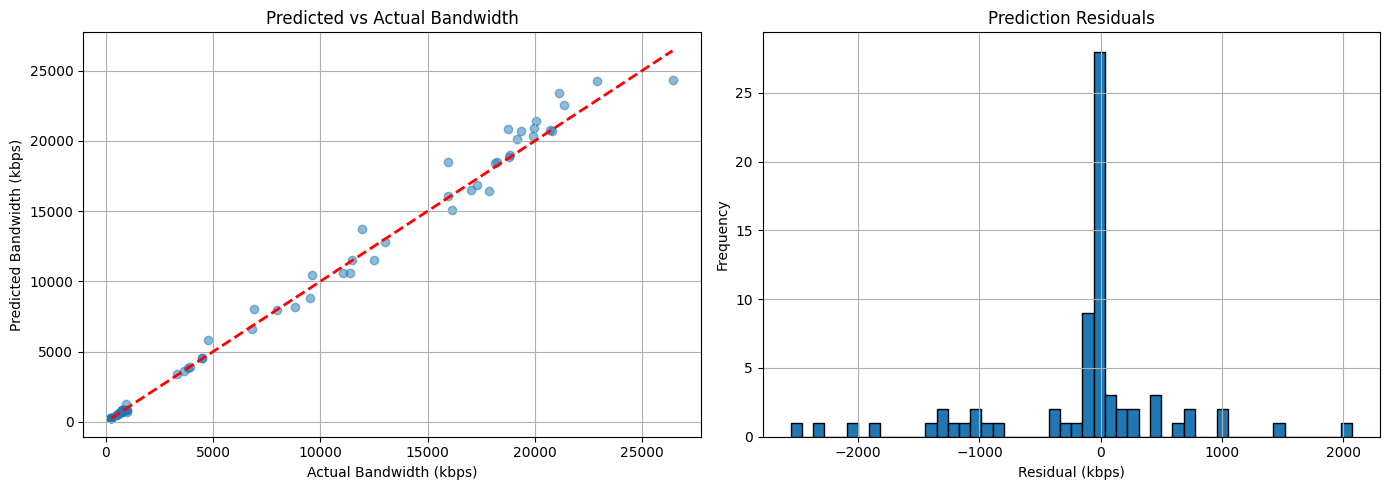

In [4]:
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)  

if model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Predicted vs Actual
    axes[0].scatter(y_test, y_pred, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Bandwidth (kbps)')
    axes[0].set_ylabel('Predicted Bandwidth (kbps)')
    axes[0].set_title('Predicted vs Actual Bandwidth')
    axes[0].grid(True)

    # Residuals
    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50, edgecolor='black')
    axes[1].set_xlabel('Residual (kbps)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Prediction Residuals')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [4]:
joblib.dump(model, "bandwidth_predictor.pkl")
joblib.dump(scaler, "bandwidth_scaler.pkl")

print("Models saved")


Models saved
